    airline   flight source_city departure_time stops   arrival_time  \
0  SpiceJet  SG-8709       Delhi        Evening  zero          Night   
1  SpiceJet  SG-8157       Delhi  Early_Morning  zero        Morning   
2   AirAsia   I5-764       Delhi  Early_Morning  zero  Early_Morning   
3   Vistara   UK-995       Delhi        Morning  zero      Afternoon   
4   Vistara   UK-963       Delhi        Morning  zero        Morning   

  destination_city    class  duration  days_left  price  
0           Mumbai  Economy      2.17          1   5953  
1           Mumbai  Economy      2.33          1   5953  
2           Mumbai  Economy      2.17          1   5956  
3           Mumbai  Economy      2.25          1   5955  
4           Mumbai  Economy      2.33          1   5955  
(300153, 11)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300153 entries, 0 to 300152
Data columns (total 11 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  

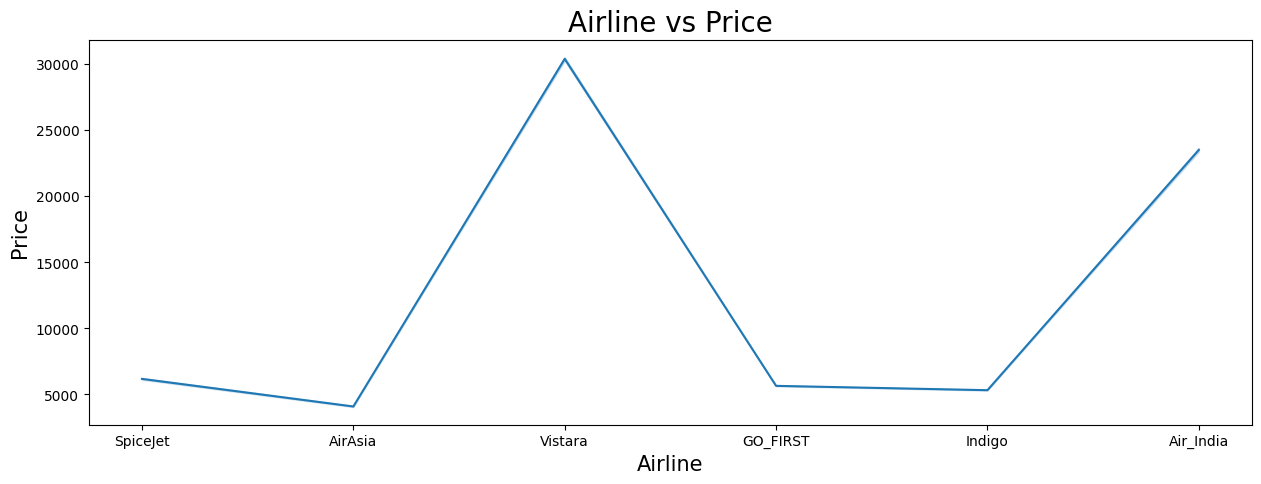

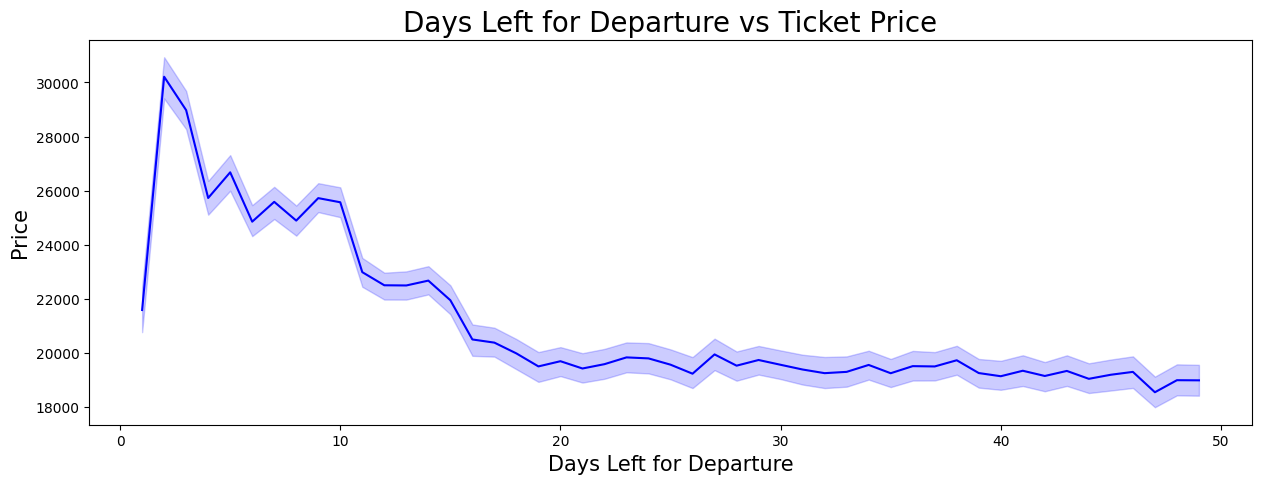

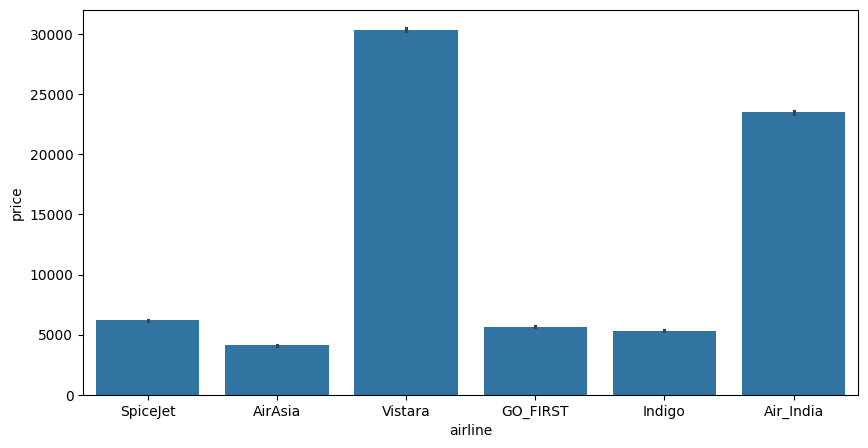

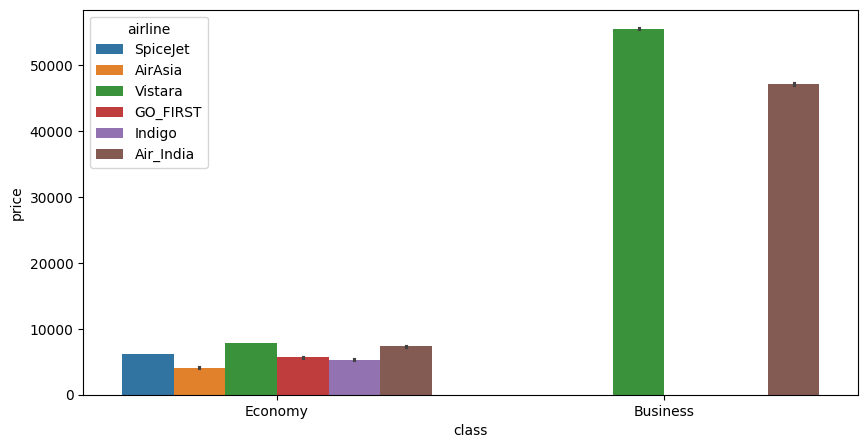

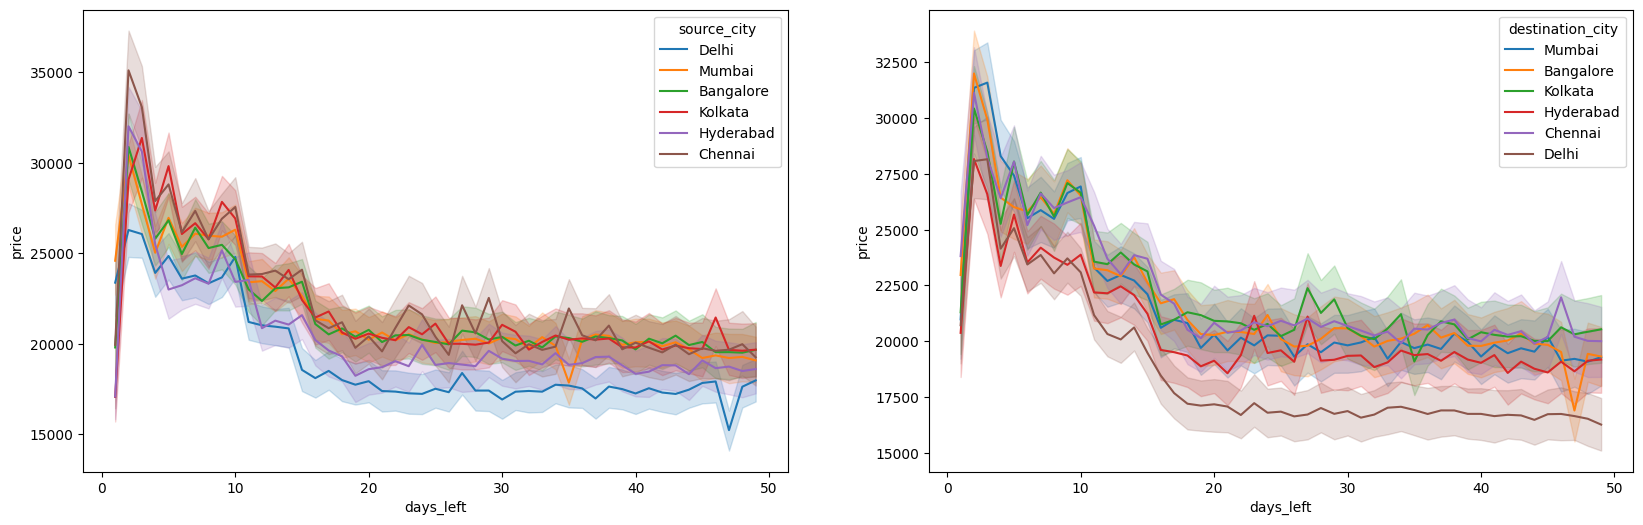

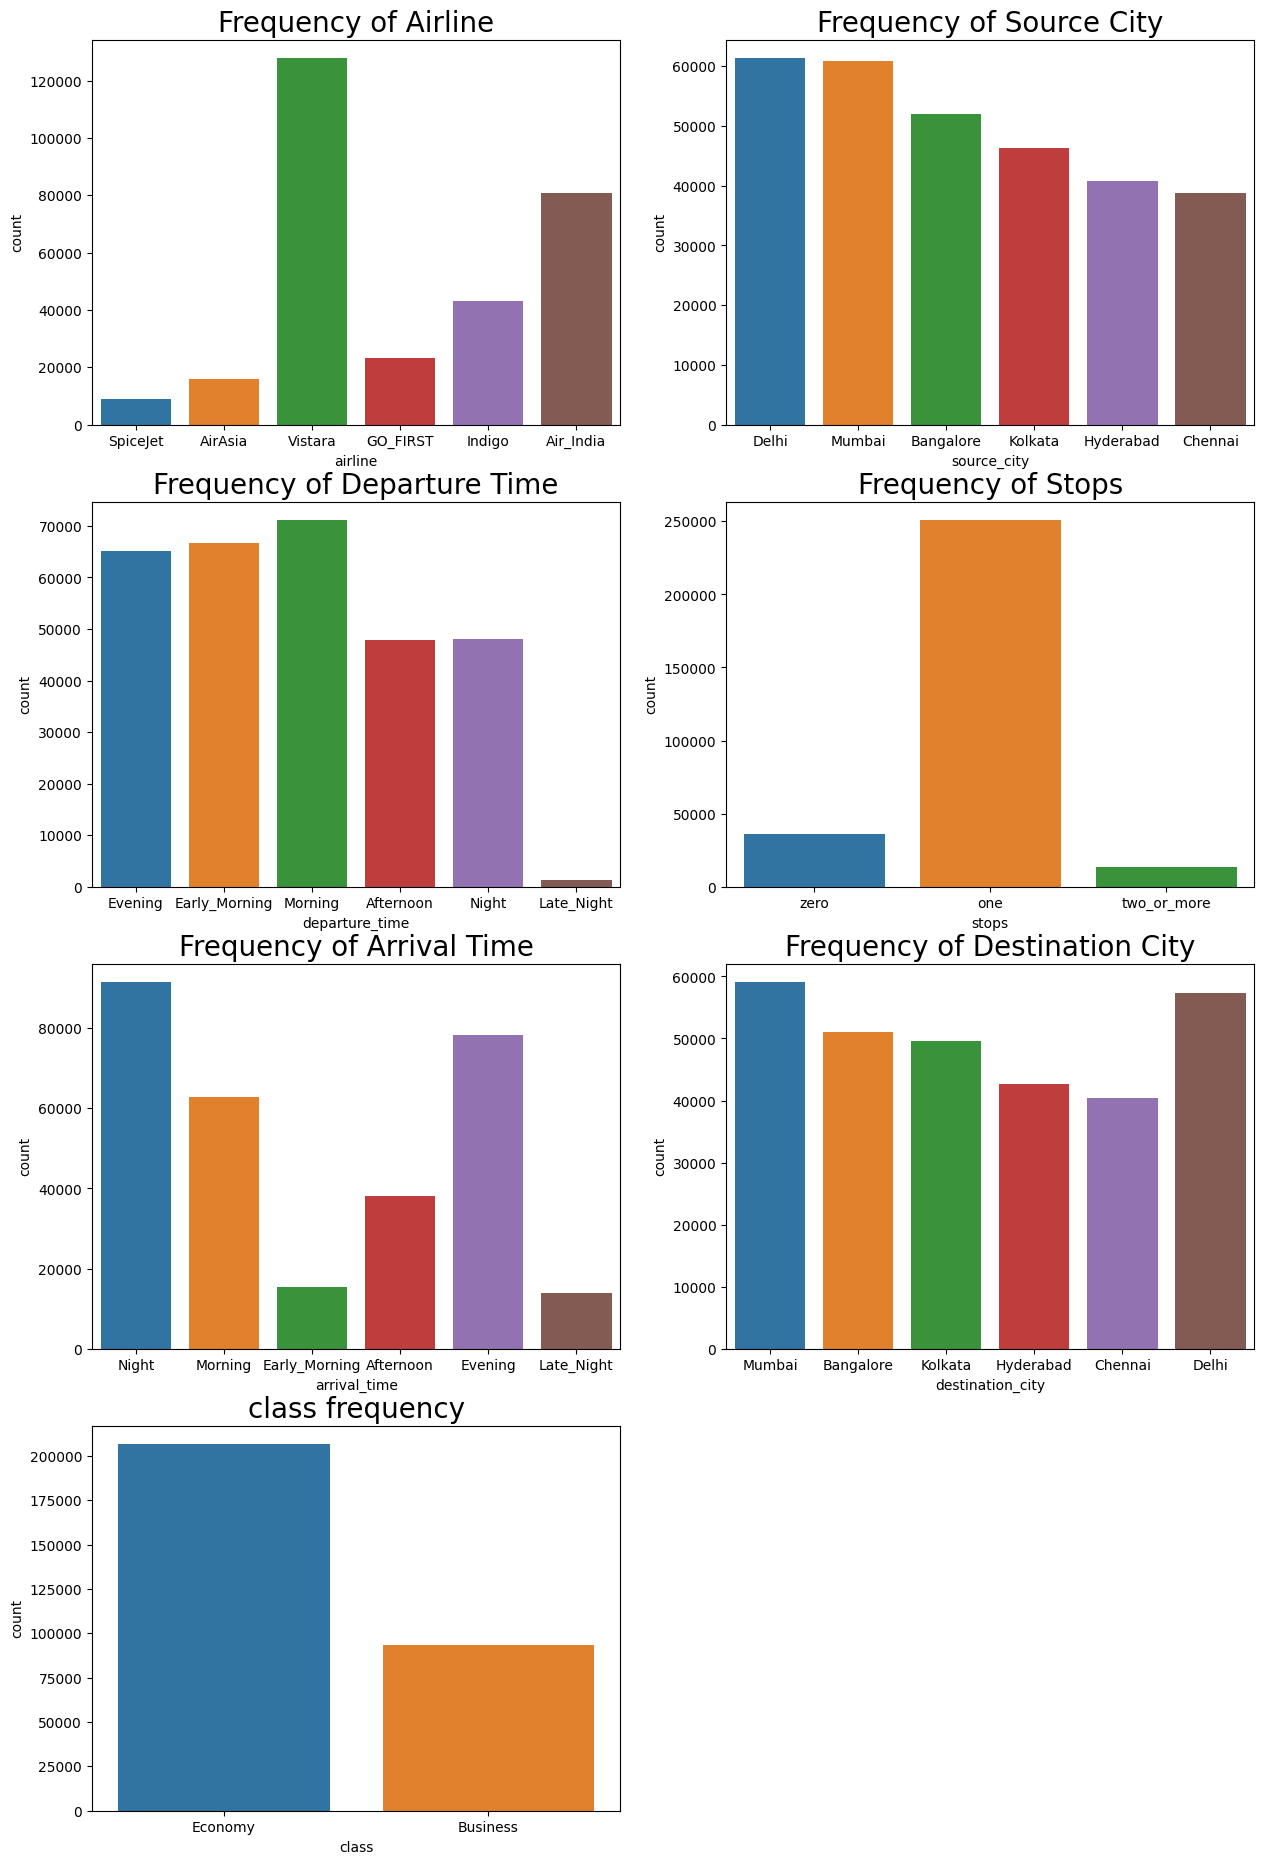

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300153 entries, 0 to 300152
Data columns (total 11 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   airline           300153 non-null  int64  
 1   flight            300153 non-null  object 
 2   source_city       300153 non-null  int64  
 3   departure_time    300153 non-null  int64  
 4   stops             300153 non-null  int64  
 5   arrival_time      300153 non-null  int64  
 6   destination_city  300153 non-null  int64  
 7   class             300153 non-null  int64  
 8   duration          300153 non-null  float64
 9   days_left         300153 non-null  int64  
 10  price             300153 non-null  int64  
dtypes: float64(1), int64(9), object(1)
memory usage: 25.2+ MB


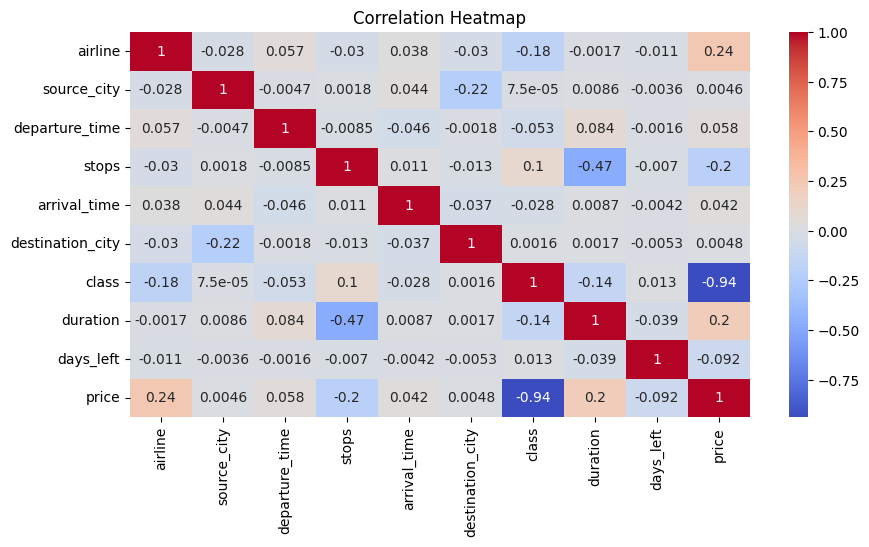

            feature       VIF
0           airline  3.393124
1       source_city  2.927766
2    departure_time  2.779427
3             stops  1.426614
4      arrival_time  3.684550
5  destination_city  2.885337
6             class  2.849370
7          duration  4.113876
8         days_left  3.976790
            feature       VIF
0           airline  3.393124
1       source_city  2.927766
2    departure_time  2.779427
3             stops  1.426614
4      arrival_time  3.684550
5  destination_city  2.885337
6             class  2.849370
7          duration  4.113876
8         days_left  3.976790
Non-numeric columns: Index(['flight'], dtype='object')


C:\Users\Mohd Shahid\AppData\Local\Temp\ipykernel_6928\2302815320.py:167: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(y_test, label='Actual')
C:\Users\Mohd Shahid\AppData\Local\Temp\ipykernel_6928\2302815320.py:168: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(y_pred, label='Predicted')
C:\Us

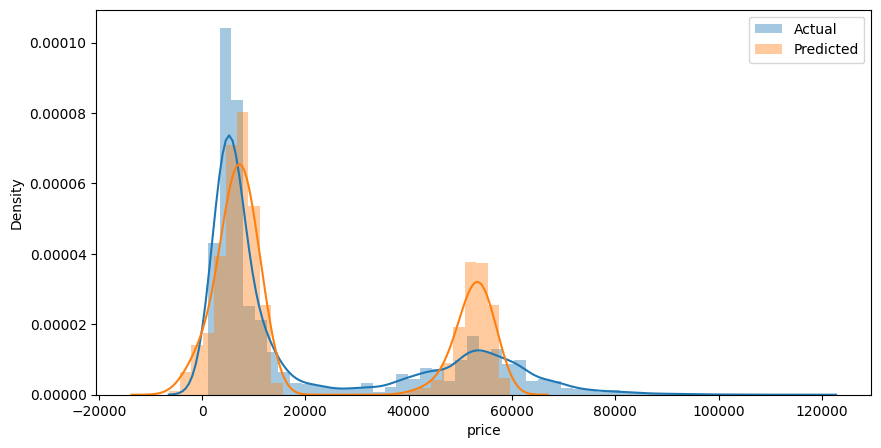

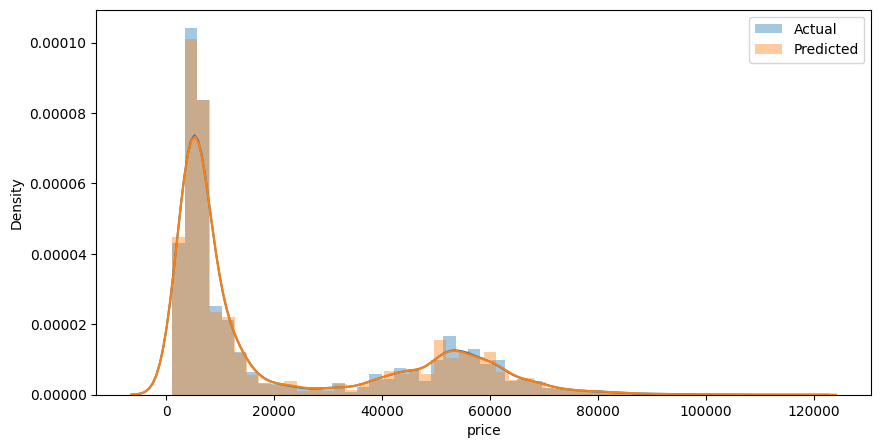

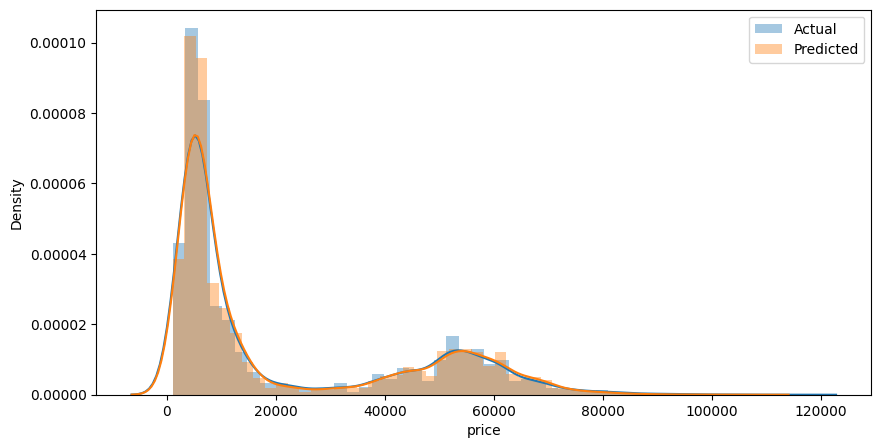

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_percentage_error
from sklearn import metrics
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression

df = pd.read_csv('Flight_Booking.csv')
df = df.drop(columns=['Unnamed: 0'])

print(df.head())
print(df.shape)
print(df.info())
print(df.describe())
print(df.isnull().sum())


plt.figure(figsize=(15,5))
sns.lineplot(x=df['airline'], y=df['price'])
plt.title('Airline vs Price', fontsize=20)


plt.xlabel('Airline', fontsize=15)
plt.ylabel('Price', fontsize=15)

plt.show()


plt.figure(figsize=(15,5))
sns.lineplot(data=df, x='days_left', y='price', color='blue')
plt.title('Days Left for Departure vs Ticket Price', fontsize=20)
plt.xlabel('Days Left for Departure', fontsize=15)
plt.ylabel('Price', fontsize=15)
plt.show()

plt.figure(figsize=(10,5))
sns.barplot(x='airline', y='price', data=df)

plt.figure(figsize=(10,5))
sns.barplot(x='class', y='price', data=df, hue='airline')
fig, ax = plt.subplots(1, 2, figsize=(20, 6))
sns.lineplot(x='days_left', y='price', data=df, hue='source_city' , ax=ax[0])
sns.lineplot(x='days_left', y='price', data=df, hue='destination_city', ax=ax[1])
plt.show()



plt.figure(figsize=(15,23))

plt.subplot(4,2,1)
sns.countplot(x=df["airline"], data=df, hue='airline')
plt.title('Frequency of Airline', fontsize=20)

plt.subplot(4,2,2)
sns.countplot(x=df["source_city"], data=df, hue='source_city' )
plt.title('Frequency of Source City', fontsize=20)

plt.subplot(4,2,3)
sns.countplot(x=df["departure_time"], data=df, hue='departure_time')
plt.title('Frequency of Departure Time', fontsize=20)

plt.subplot(4,2,4)
sns.countplot(x=df["stops"], data=df, hue='stops')
plt.title('Frequency of Stops', fontsize=20)

plt.subplot(4,2,5)
sns.countplot(x=df["arrival_time"], data=df, hue='arrival_time')
plt.title('Frequency of Arrival Time', fontsize=20)

plt.subplot(4,2,6)
sns.countplot(x=df["destination_city"], data=df, hue='destination_city')
plt.title('Frequency of Destination City', fontsize=20)

plt.subplot(4,2,7)
sns.countplot(x=df["class"], data=df, hue='class')
plt.title('class frequency', fontsize=20)


plt.show()


le=LabelEncoder()
df['airline'] = le.fit_transform(df['airline'])
df['source_city']=le.fit_transform(df['source_city'])
df['departure_time']=le.fit_transform(df['departure_time'])
df['stops']=le.fit_transform(df['stops'])
df['arrival_time']=le.fit_transform(df['arrival_time'])
df['destination_city']=le.fit_transform(df['destination_city'])
df['class']=le.fit_transform(df['class'])
df.info()

df_numeric = df.select_dtypes(include=['float64', 'int64'])


plt.figure(figsize=(10, 5))
sns.heatmap(df_numeric.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

col_list = []
for col in df.columns:
    if ((df[col].dtype != 'object') & (col != 'price')):
        col_list.append(col)
        
x = df[col_list]
vif_data = pd.DataFrame()
vif_data["feature"] = x.columns
vif_data["VIF"] = [variance_inflation_factor(x.values, i) for i in range(len(x.columns))]
print(vif_data)


df.drop(columns=['stops'])

col_list = []
for col in df.columns:
    if ((df[col].dtype != 'object') & (col != 'price')):
        col_list.append(col)
x = df[col_list]
vif_data = pd.DataFrame()
vif_data["feature"] = x.columns
vif_data['VIF'] = [variance_inflation_factor(x.values, i) for i in range(len(x.columns))]
print(vif_data)



x = df.drop(columns=['price'])
y = df['price']
non_numeric_columns = x.select_dtypes(include=['object']).columns
print("Non-numeric columns:", non_numeric_columns)
x = x.drop(columns=non_numeric_columns)

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

sc = StandardScaler()
x_train = sc.fit_transform(x_train)
x_test = sc.transform(x_test)

lr = LinearRegression()
lr.fit(x_train, y_train)
y_pred = lr.predict(x_test)
difference = pd.DataFrame(np.c_[y_test, y_pred], columns=['Actual Value', 'Predicted Value'])
difference



plt.figure(figsize=(10, 5))
r2_score(y_test, y_pred)


mean_abs_error = metrics.mean_absolute_error(y_test, y_pred)


mean_abs_percentage_error_value = mean_absolute_percentage_error(y_test, y_pred)


mean_sq_error = metrics.mean_squared_error(y_test, y_pred)


root_mean_sq_error = np.sqrt(metrics.mean_squared_error(y_test, y_pred))

sns.distplot(y_test, label='Actual')
sns.distplot(y_pred, label='Predicted')
plt.legend()

plt.figure(figsize=(10, 5))
dt = DecisionTreeRegressor()
dt.fit(x_train, y_train)
y_pred = dt.predict(x_test)
r2_score(y_test, y_pred)
mean_abs_error = metrics.mean_absolute_error(y_test, y_pred)
mean_abs_percentage_error_value = mean_absolute_percentage_error(y_test, y_pred)
mean_sq_error = metrics.mean_squared_error(y_test, y_pred)
root_mean_sq_error = np.sqrt(metrics.mean_squared_error(y_test, y_pred))

sns.distplot(y_test, label='Actual')
sns.distplot(y_pred, label='Predicted')
plt.legend()



plt.figure(figsize=(10, 5))
rfr = RandomForestRegressor()
rfr.fit(x_train, y_train)
y_pred = rfr.predict(x_test)
r2_score(y_test, y_pred)
mean_abs_error = metrics.mean_absolute_error(y_test, y_pred)
mean_abs_percentage_error_value = mean_absolute_percentage_error(y_test, y_pred)
mean_sq_error = metrics.mean_squared_error(y_test, y_pred)
root_mean_sq_error = np.sqrt(metrics.mean_squared_error(y_test, y_pred))
sns.distplot(y_test, label='Actual')
sns.distplot(y_pred, label='Predicted')
plt.legend()

